# Data Science Salary Prediction

Predicts annual salary (USD) from job & company attributes.

**Key point:** this notebook avoids the *data leakage* that inflated the earlier version's score. We do **not** use any salary-derived bucket as an input, and we One-Hot encode categories instead of turning them into arbitrary integers.

## 1. Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

pd.set_option('display.max_columns', None)

## 2. Load data

In [6]:
df = pd.read_csv('Latest_Data_Science_Salaries.csv')
print(df.shape)
df.head()

(3300, 11)


,Job Title,Employment Type,Experience Level,Expertise Level,Salary,Salary Currency,Company Location,Salary in USD,Employee Residence,Company Size,Year
0,Data Engineer,Full-Time,Senior,Expert,210000,United States Dollar,United States,210000,United States,Medium,2023
1,Data Engineer,Full-Time,Senior,Expert,165000,United States Dollar,United States,165000,United States,Medium,2023
2,Data Engineer,Full-Time,Senior,Expert,185900,United States Dollar,United States,185900,United States,Medium,2023
3,Data Engineer,Full-Time,Senior,Expert,129300,United States Dollar,United States,129300,United States,Medium,2023
4,Data Scientist,Full-Time,Senior,Expert,140000,United States Dollar,United States,140000,United States,Medium,2023


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3300 entries, 0 to 3299
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Job Title           3300 non-null   object
 1   Employment Type     3300 non-null   object
 2   Experience Level    3300 non-null   object
 3   Expertise Level     3300 non-null   object
 4   Salary              3300 non-null   int64 
 5   Salary Currency     3300 non-null   object
 6   Company Location    3300 non-null   object
 7   Salary in USD       3300 non-null   int64 
 8   Employee Residence  3300 non-null   object
 9   Company Size        3300 non-null   object
 10  Year                3300 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 283.7+ KB


## 3. Quick EDA

In [11]:
df['Experience Level'].value_counts()

Experience Level
Senior       2065
Mid           797
Entry         292
Executive     146
Name: count, dtype: int64

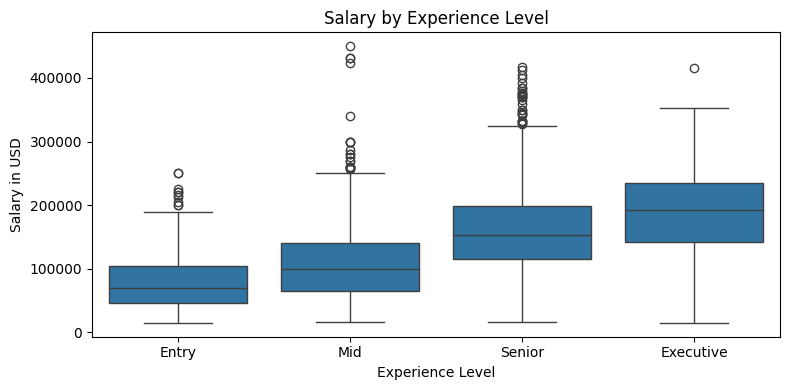

In [13]:
plt.figure(figsize=(8,4))
order = df.groupby('Experience Level')['Salary in USD'].median().sort_values().index
sns.boxplot(data=df, x='Experience Level', y='Salary in USD', order=order)
plt.title('Salary by Experience Level')
plt.tight_layout()
plt.show()

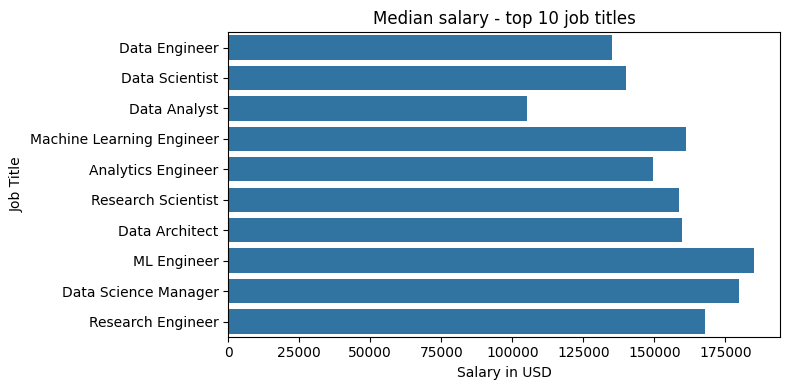

In [14]:
plt.figure(figsize=(8,4))
top = df['Job Title'].value_counts().head(10).index
sns.barplot(data=df[df['Job Title'].isin(top)], x='Salary in USD', y='Job Title',
            estimator='median', order=top, errorbar=None)
plt.title('Median salary - top 10 job titles')
plt.tight_layout()
plt.show()

## 4. Define features and target

We drop `Salary` and `Salary Currency` (raw local-currency salary = leakage) and predict `Salary in USD`.

In [17]:
TARGET = 'Salary in USD'
CATEGORICAL = ['Job Title', 'Employment Type', 'Experience Level', 'Expertise Level',
               'Company Location', 'Company Size', 'Employee Residence']
NUMERIC = ['Year']
FEATURES = CATEGORICAL + NUMERIC

df = df.dropna(subset=FEATURES + [TARGET])
X = df[FEATURES]
y = df[TARGET]
X.head()

,Job Title,Employment Type,Experience Level,Expertise Level,Company Location,Company Size,Employee Residence,Year
0,Data Engineer,Full-Time,Senior,Expert,United States,Medium,United States,2023
1,Data Engineer,Full-Time,Senior,Expert,United States,Medium,United States,2023
2,Data Engineer,Full-Time,Senior,Expert,United States,Medium,United States,2023
3,Data Engineer,Full-Time,Senior,Expert,United States,Medium,United States,2023
4,Data Scientist,Full-Time,Senior,Expert,United States,Medium,United States,2023


## 5. Build pipeline (One-Hot + RandomForest)

In [21]:
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL)],
    remainder='passthrough'  # keeps Year
)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=24))
])

## 6. Train / test split and fit

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'Test R^2 : {r2_score(y_test, y_pred):.3f}')
print(f'Test MAE : ${mean_absolute_error(y_test, y_pred):,.0f}')

Test R^2 : 0.445
Test MAE : $38,503


## 7. Compare a few models

In [26]:
results = []
for name, reg in [
    ('Linear Regression', LinearRegression()),
    ('Random Forest', RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=24)),
]:
    pipe = Pipeline([('preprocessor', preprocessor), ('regressor', reg)])
    pipe.fit(X_train, y_train)
    p = pipe.predict(X_test)
    results.append({'model': name, 'R2': r2_score(y_test, p), 'MAE': mean_absolute_error(y_test, p)})

pd.DataFrame(results).sort_values('R2', ascending=False)

,model,R2,MAE
1,Random Forest,0.444951,38502.617463
0,Linear Regression,0.403434,39985.318915


## 8. Cross-validation (more reliable than a single split)

In [28]:
cv = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f'5-fold CV R^2: {cv.mean():.3f} (+/- {cv.std():.3f})')

5-fold CV R^2: 0.319 (+/- 0.053)


## 9. Predict on a new example

In [30]:
example = pd.DataFrame([{
    'Job Title': 'Data Scientist',
    'Employment Type': 'Full-Time',
    'Experience Level': 'Senior',
    'Expertise Level': 'Expert',
    'Company Location': 'United States',
    'Company Size': 'Medium',
    'Employee Residence': 'United States',
    'Year': 2023
}])[FEATURES]

pred = model.predict(example)[0]
print(f'Predicted salary: ${pred:,.0f}')

Predicted salary: $182,045


## 10. Save the model + metadata

This is the file the Gradio app (`app.py`) loads.

In [32]:
choices = {c: sorted(df[c].dropna().unique().tolist()) for c in CATEGORICAL}
choices['Year'] = sorted(int(v) for v in df['Year'].dropna().unique())

artifact = {
    'model': model,
    'features': FEATURES,
    'categorical': CATEGORICAL,
    'numeric': NUMERIC,
    'choices': choices,
    'metrics': {'r2': r2_score(y_test, y_pred), 'mae': mean_absolute_error(y_test, y_pred)}
}
joblib.dump(artifact, 'salary_model.joblib')
print('Saved -> salary_model.joblib')

Saved -> salary_model.joblib
